In [1]:
import numpy as np
import itertools
from InfAdjFPFiniteDiffApp import InfAdjFPFiniteDiff_OriginalOperator
import matplotlib.pyplot as plt

In [2]:
dim = 2
mpl = 1.221e19
Pi = 100**0.5
M = 1e16 / mpl
phic = np.sqrt(2) * M
Lambda = 5.4e15 / mpl * (Pi / 10)**(-1) * M * phic**0.5
nWaterfall = 1
mu1 = Pi**2 * M**(-2) * phic**(-1)
mu2 = 10
psirc = (nWaterfall * Lambda**4 * Pi / 48 / 2**0.5 / np.pi**1.5)**0.5

def infPotFunc(Phi):
    phi = Phi[0]
    psir = Phi[1]
    return float(Lambda**4 * ((1 - (psir / M)**2)**2 + 2 * (phi * psir / phic / M)**2 + (phi - phic) / mu1 - ((phi - phic) / mu2)**2))
    
def infPotDerivFunc_phi(Phi):
    phi = Phi[0]
    psir = Phi[1]
    return float(Lambda**4 * (4 * phi * (psir / phic / M)**2 + 1 / mu1 - 2 * (phi - phic) / mu2**2))
    
def infPotDerivFunc_psir(Phi):
    phi = Phi[0]
    psir = Phi[1]
    return float(Lambda**4 * (-4 * psir / M**2 * (1 - (psir / M)**2) + 4 * psir * (phi / phic / M)**2))

def infPotDeriv2Func_phi(Phi):
    psir = Phi[1]
    return float(Lambda**4 * (4 * (psir / phic / M)**2 - 2 / mu2**2))

def infPotDeriv2Func_psir(Phi):
    phi = Phi[0]
    psir = Phi[1]
    return float(Lambda**4 * (-4 / M**2 + 12 * (psir / M / M)**2 + 4 * (phi / phic / M)**2))


infPotentialDerivFuncs = [infPotDerivFunc_phi, infPotDerivFunc_psir]
infPotentialDeriv2Funcs = [infPotDeriv2Func_phi, infPotDeriv2Func_psir]

nGrid = 64
#phimin = 0.999995 * phic
phimin = phic - 20 / mu1
phimax = phic + 20 / mu1
#psimax = 1e-4 * M
psimax = 5 * psirc
#psimin = 0.1 * psirc
customGrid_phi = np.linspace(phimin, phimax, nGrid)
#customGrid_psir = np.concatenate([-np.exp(np.linspace(np.log(psimax), np.log(psimin), nGrid // 2)), np.exp(np.linspace(np.log(psimin), np.log(psimax), nGrid // 2))])
customGrid_psir = np.linspace(-psimax, psimax, nGrid)

In [3]:
fpFinDiff_NeuNeu = InfAdjFPFiniteDiff_OriginalOperator(
    dim,
    infPotFunc,
    infPotentialDerivFuncs,
    [nGrid, nGrid],
    [phimax, psimax],
    [phimin, -psimax],
    ["Neumann0", "Neumann0"],
    ["Neumann0", "Neumann0"],
    customGrid=[customGrid_phi, customGrid_psir]
)

# ポテンシャルが一定以下ならインフレーション領域外として、当該点に対応する行列の要素を0とする
customGrid_phi_woEnd = customGrid_phi[1:-1]
customGrid_psir_woEnd = customGrid_psir[1:-1]
vTh = (1 - 4.746948205088901201275e-16) * Lambda**4
maskMat = np.full((len(customGrid_phi_woEnd), len(customGrid_psir_woEnd)), False)
for i1 in range(len(customGrid_phi_woEnd)):
    for i2 in range(len(customGrid_psir_woEnd)):
        if infPotFunc([customGrid_phi_woEnd[i1], customGrid_phi_woEnd[i2]]) < vTh:
            maskMat[i1, i2] = True
            fpFinDiff_NeuNeu[i1, i2] = 0

eigVals_NeuNeu, eigVecs_NeuNeu = np.linalg.eig(fpFinDiff_NeuNeu)
eigVecsSort_NeuNeu = eigVecs_NeuNeu.T[np.argsort(eigVals_NeuNeu)]
eigValsSort_NeuNeu = np.sort(eigVals_NeuNeu)

In [4]:
fpFinDiff_DirDir = InfAdjFPFiniteDiff_OriginalOperator(
    dim,
    infPotFunc,
    infPotentialDerivFuncs,
    [nGrid, nGrid],
    [phimax, psimax],
    [phimin, -psimax],
    ["Dirichlet", "Dirichlet"],
    ["Dirichlet", "Dirichlet"],
    customGrid=[customGrid_phi, customGrid_psir]
)

for i1 in range(len(customGrid_phi_woEnd)):
    for i2 in range(len(customGrid_psir_woEnd)):
        if maskMat[i1, i2]: fpFinDiff_DirDir[i1, i2] = 0

eigVals_DirDir, eigVecs_DirDir = np.linalg.eig(fpFinDiff_DirDir)
eigVecsSort_DirDir = eigVecs_DirDir.T[np.argsort(eigVals_DirDir)]
eigValsSort_DirDir = np.sort(eigVals_DirDir)

c:\Users\koich\anaconda3\lib\site-packages\numpy\core\_asarray.py:102: ComplexWarning: Casting complex values to real discards the imaginary part
  return array(a, dtype, copy=False, order=order)


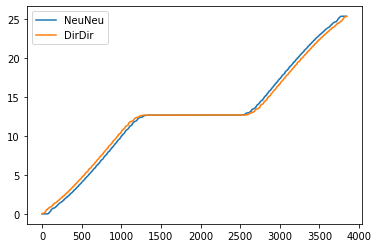

In [5]:
ax = plt.gca()
plt.plot(eigValsSort_NeuNeu, label = "NeuNeu")
plt.plot(eigValsSort_DirDir, label = "DirDir")
plt.legend()
plt.show()

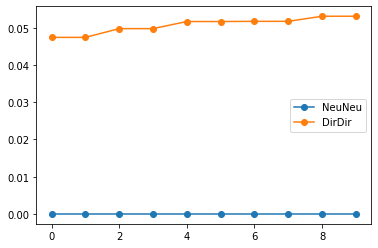

In [6]:
ax = plt.gca()
plt.plot(np.arange(10), eigValsSort_NeuNeu[:10], marker='o', label = "NeuNeu")
plt.plot(np.arange(10), eigValsSort_DirDir[:10], marker='o', label = "DirDir")
plt.legend()
plt.show()

In [7]:
np.set_printoptions(formatter={'float': '{:.30e}'.format})
print(eigValsSort_NeuNeu[0:10])
print(eigValsSort_DirDir[0:10])
np.set_printoptions()

[-9.32734154e-10-1.88220183j -9.32734154e-10+1.88220183j
 -1.55805437e-11-1.77967171j -1.55805437e-11+1.77967171j
 -5.24247091e-14+0.j          4.20303588e-14+0.j
  7.55564101e-12-1.46880003j  7.55564101e-12+1.46880003j
  7.65564695e-12-2.00997574j  7.65564695e-12+2.00997574j]
[0.04740722-0.9823213j  0.04740722+0.9823213j  0.04975601-1.01805547j
 0.04975601+1.01805547j 0.05166301-1.38126548j 0.05166301+1.38126548j
 0.05171274-1.48955385j 0.05171274+1.48955385j 0.05308166-1.2923007j
 0.05308166+1.2923007j ]


「phi上下端：ノイマン、psir上下端：ノイマン」と「phi上下端：ディリクレ、psir上端：ディリクレ、psir下端：ノイマン」で、固有値ほぼ一致

c:\Users\koich\anaconda3\lib\site-packages\matplotlib\contour.py:1454: ComplexWarning: Casting complex values to real discards the imaginary part
  self.zmax = float(z.max())
c:\Users\koich\anaconda3\lib\site-packages\matplotlib\contour.py:1455: ComplexWarning: Casting complex values to real discards the imaginary part
  self.zmin = float(z.min())
c:\Users\koich\anaconda3\lib\site-packages\numpy\ma\core.py:2825: ComplexWarning: Casting complex values to real discards the imaginary part
  _data = np.array(data, dtype=dtype, copy=copy,


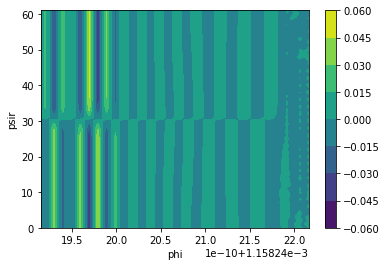

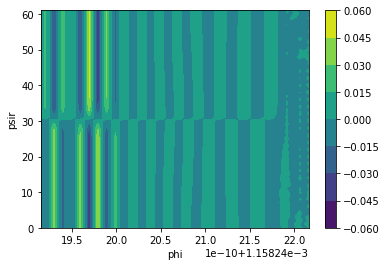

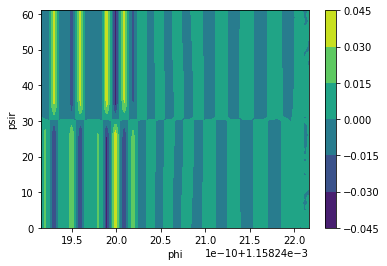

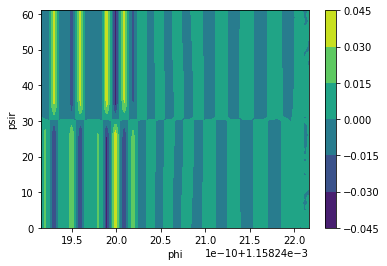

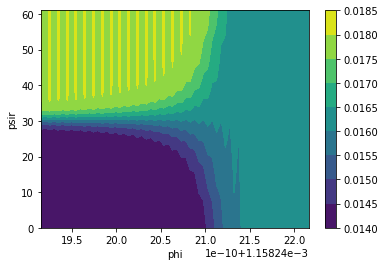

In [8]:
# 固有関数のプロット
for iEig in range(5):   
    fig, ax1 = plt.subplots(1)
    cntr1 = ax1.contourf(customGrid_phi[1:-1], np.arange(nGrid-2), np.reshape(eigVecsSort_NeuNeu[iEig], (nGrid-2, nGrid-2)).T)
    fig.colorbar(cntr1, ax=ax1)
    ax1.set_xlabel("phi")
    ax1.set_ylabel("psir")
    plt.show()

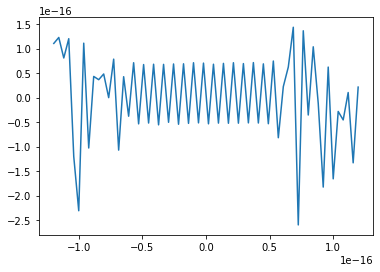

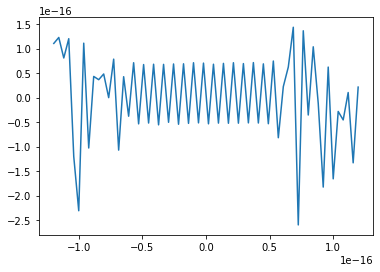

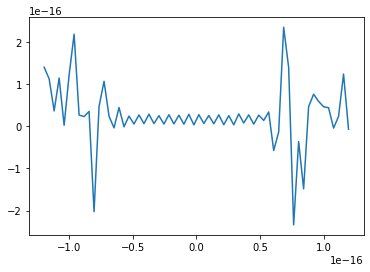

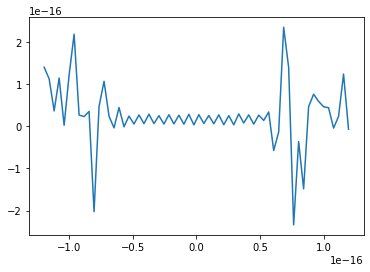

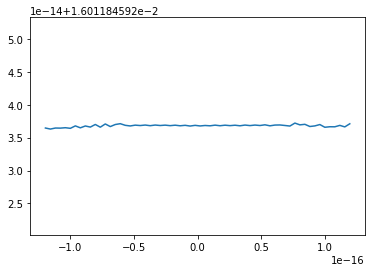

In [9]:
for iEig in range(5):
    ax = plt.gca()
    plt.plot(customGrid_psir[1:-1], np.reshape(eigVecsSort_NeuNeu[iEig], (nGrid-2, nGrid-2))[-1,:])
    plt.show()

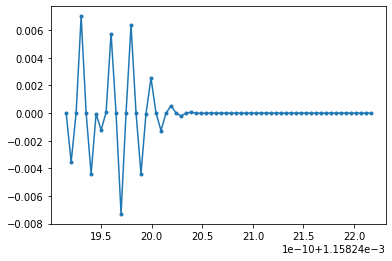

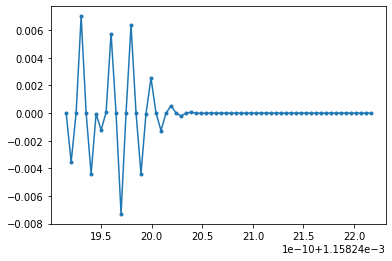

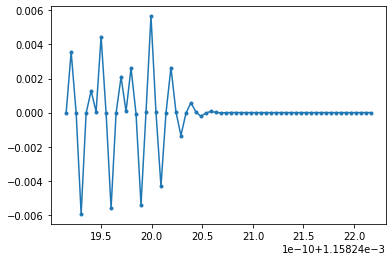

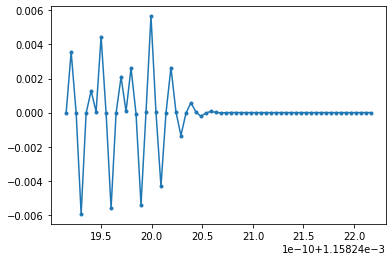

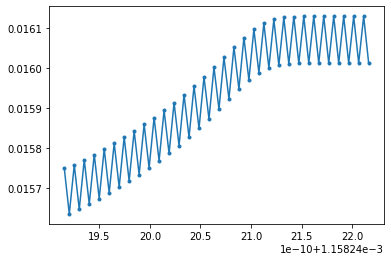

In [10]:
for iEig in range(5):
    ax = plt.gca()
    plt.plot(customGrid_phi[1:-1], np.reshape(eigVecsSort_NeuNeu[iEig], (nGrid-2, nGrid-2))[:,30], marker=".")
    plt.show()

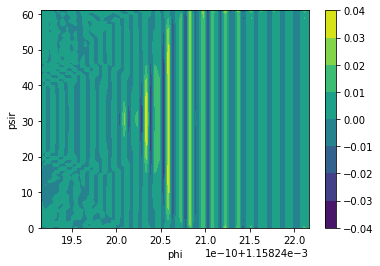

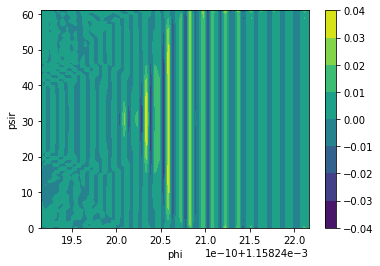

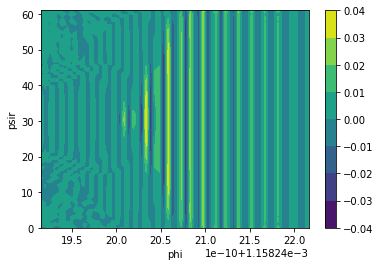

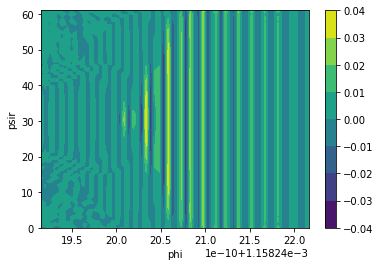

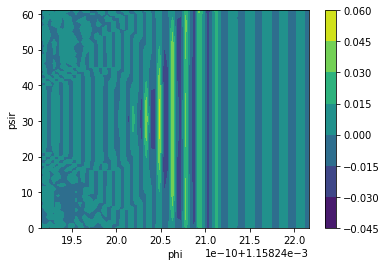

In [11]:
# 固有関数のプロット
for iEig in range(5):   
    fig, ax1 = plt.subplots(1)
    cntr1 = ax1.contourf(customGrid_phi[1:-1], np.arange(nGrid-2), np.reshape(eigVecsSort_DirDir[iEig], (nGrid-2, nGrid-2)).T)
    fig.colorbar(cntr1, ax=ax1)
    ax1.set_xlabel("phi")
    ax1.set_ylabel("psir")
    plt.show()

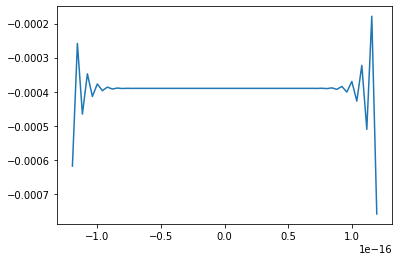

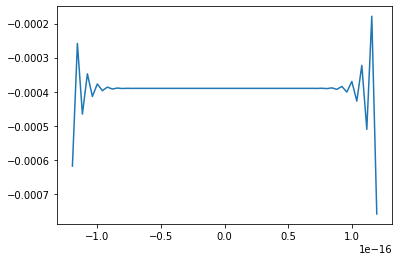

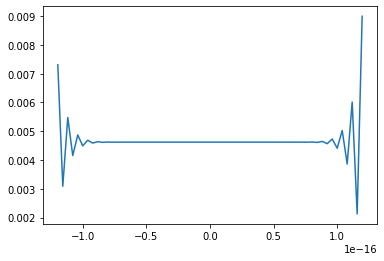

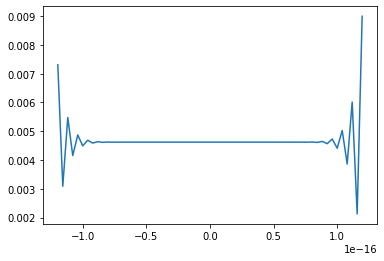

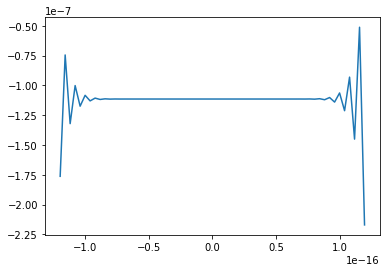

In [12]:
for iEig in range(5):
    ax = plt.gca()
    plt.plot(customGrid_psir[1:-1], np.reshape(eigVecsSort_DirDir[iEig], (nGrid-2, nGrid-2))[-1,:])
    plt.show()

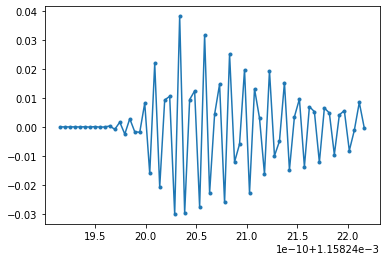

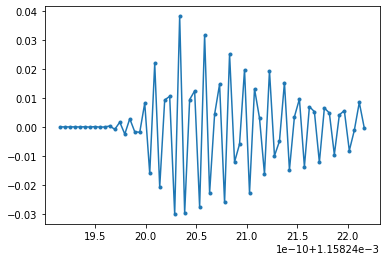

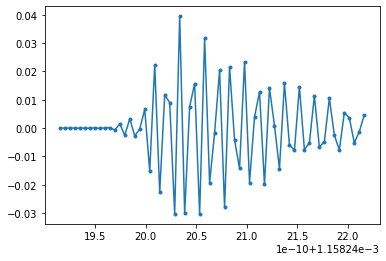

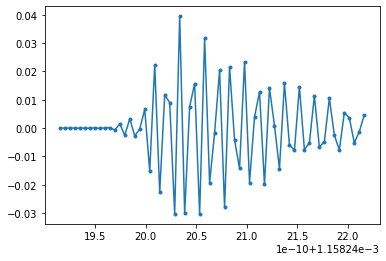

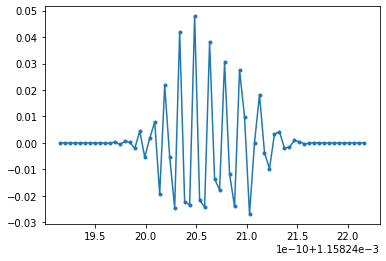

In [13]:
for iEig in range(5):
    ax = plt.gca()
    plt.plot(customGrid_phi[1:-1], np.reshape(eigVecsSort_DirDir[iEig], (nGrid-2, nGrid-2))[:,30], marker=".")
    plt.show()

In [14]:
np.set_printoptions(formatter={'float': '{:.30e}'.format})
print(phimin,phic,phimax)
print(customGrid_phi)
np.set_printoptions()

0.0011582419104445988 0.0011582420658256308 0.0011582422212066629
[1.158241910444598793059056696109e-03 1.158241915377329882969048568953e-03
 1.158241920310061189719474938897e-03 1.158241925242792279629466811741e-03
 1.158241930175523586379893181686e-03 1.158241935108254676289885054530e-03
 1.158241940040985766199876927374e-03 1.158241944973717072950303297318e-03
 1.158241949906448162860295170162e-03 1.158241954839179469610721540107e-03
 1.158241959771910559520713412951e-03 1.158241964704641649430705285795e-03
 1.158241969637372956181131655740e-03 1.158241974570104046091123528583e-03
 1.158241979502835352841549898528e-03 1.158241984435566442751541771372e-03
 1.158241989368297532661533644216e-03 1.158241994301028839411960014161e-03
 1.158241999233759929321951887005e-03 1.158242004166491236072378256949e-03
 1.158242009099222325982370129793e-03 1.158242014031953415892362002637e-03
 1.158242018964684722642788372582e-03 1.158242023897415812552780245426e-03
 1.158242028830147119303206615371e

In [29]:
def infPotInvDiffFromCri(Phi):
    phi = Phi[0]
    psir = Phi[1]
    v_v0 = Lambda**4 * (-2 * (psir / M)**2 + (psir / M)**4 + 2 * (phi * psir / phic / M)**2 + (phi - phic) / mu1 - ((phi - phic) / mu2)**2)
    return -v_v0 / infPotFunc([phi, psir]) / infPotFunc([phic, 0])

<ipython-input-32-cd04e38760ae>:7: RuntimeWarning: overflow encountered in exp
  wMat[i,j] = np.exp(infPotInvDiffMat[i,j]) / infPotFunc([customGrid_phi[i], customGrid_psir[j]])


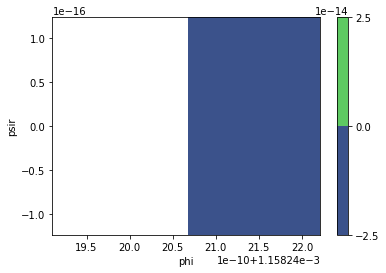

In [32]:
wMat = np.zeros((nGrid, nGrid))
infPotInvDiffMat = np.zeros((nGrid, nGrid))

for i in range(nGrid):
    for j in range(nGrid):
        infPotInvDiffMat[i,j] = infPotInvDiffFromCri([customGrid_phi[i], customGrid_psir[j]])
        wMat[i,j] = np.exp(infPotInvDiffMat[i,j]) / infPotFunc([customGrid_phi[i], customGrid_psir[j]])

fig, ax1 = plt.subplots(1)
cntr1 = ax1.contourf(customGrid_phi, customGrid_psir, wMat.T)
fig.colorbar(cntr1, ax=ax1)
ax1.set_xlabel("phi")
ax1.set_ylabel("psir")
plt.show()

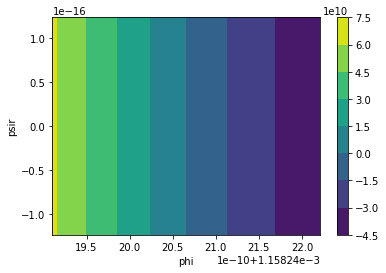

In [33]:
fig, ax1 = plt.subplots(1)
cntr1 = ax1.contourf(customGrid_phi, customGrid_psir, infPotInvDiffMat.T)
fig.colorbar(cntr1, ax=ax1)
ax1.set_xlabel("phi")
ax1.set_ylabel("psir")
plt.show()